In [5]:
from pathlib import Path
import sys
project_root = Path(r"c:\Users\chem-bras5436\Documents\ml_mp_movements")
sys.path.insert(0, str(project_root))

from simulator import gen_data
from simulator.pipeline import movie_simulator, m2c, c2m
from simulator.background import gen_random_mov_stack
from simulator.ratiometric import gen_ratiometric_movie
from simulator import constants

import torch
import numpy as np
import matplotlib.pyplot as plt

In [6]:
test = gen_data(batch_size=64)

In [7]:
batch_size = (
    test[0].numel()
    + test[1]["heatmap"].numel()
    + test[1]["offset"].numel()
    + test[1]["orientation"].numel()
)

print(f"Batch size: {batch_size * 4 / 1e9:.1f} GB in float32")

Batch size: 4.1 GB in float32


In [ ]:
mov_stack = gen_random_mov_stack()

navg = constants.DEFAULT_NAVG

In [85]:
# -- data --
MOVIE_LENGTH = 500  # frames per sampled background window (before navg cropping)
MOV_THUMBNAIL_SIZE = None  # None -> simulator's own train/val default (64 / 48 px)
NAVG = (
    5  # ratiometric window size; also excludes events from the first/last NAVG frames
)
EVENT_DENSITY_RANGE = (0.05, 2.5)  # events / um^2 / s, uniformly sampled per movie

# -- dataset / dataloader --
TRAIN_DATASET_SIZE = (
    512  # samples per training epoch (arbitrary -- data is generated, not finite)
)
VAL_DATASET_SIZE = 64  # samples per validation pass
VAL_SEED = 0  # fixed base_seed -> the same 64 validation samples every epoch, comparable across epochs
BATCH_SIZE = 1  # micro-batch actually on the GPU; sets peak memory (see note above)
ACCUM_STEPS = 8  # micro-batches accumulated per optimizer step -> effective batch = BATCH_SIZE * ACCUM_STEPS
NUM_WORKERS = (
    0  # DataLoader worker processes generating samples in parallel with GPU compute
)

# -- model --
N_CHANNELS = 1  # single-channel (grayscale) ratiometric input
FEAT_CHANNELS = 3  # EventDetector default
MIN_CHANNELS = 8  # EventDetector/CustomUNet default

# -- optimization --
LEARNING_RATE = (
    1e-3  # torch.optim.Adam's own default; tune from here based on the loss curve
)
LAMBDA_OFFSET = 1.0  # loss_fn's own default, spelled out here for visibility
LAMBDA_ORIENTATION = 0.8  # loss_fn's own default, spelled out here for visibility
NUM_EPOCHS = 50

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}")

device: cuda


In [86]:
def load_checkpoint(
    path: Path,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer | None = None,
) -> tuple[int, float]:
    """Load a checkpoint saved by `save_checkpoint`, in place.

    Args:
        path: Checkpoint file to load.
        model: Model to load `state_dict` into.
        optimizer: If given, optimizer to load `state_dict` into too; omit
            to load only model weights (e.g. for inference-only use).

    Returns:
        A tuple of (epoch, best_val_loss) the checkpoint was saved at, so
        training can resume from `epoch + 1`.
    """
    checkpoint = torch.load(path, map_location=next(model.parameters()).device)
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    return checkpoint["epoch"], checkpoint["best_val_loss"]

In [87]:
best_fp = Path(
    r"C:\Users\chem-bras5436\Documents\ml_mp_movements\data\checkpoints\20260909_204409\best.pt"
)

In [88]:
from model.model import EventDetector

In [89]:
model = EventDetector(
    n_channels=N_CHANNELS, feat_channels=FEAT_CHANNELS, min_channels=MIN_CHANNELS
).to(DEVICE)

In [90]:
load_checkpoint(path=best_fp, model=model)

(41, 0.19103635533247143)

In [152]:
events = [
    [32, 11, 100, m2c(-2500)],
    [11, 53, 100, m2c(2500)],
    [53.05, 53, 100, m2c(-2500)],
    [52.95, 53, 100, m2c(2500)],
    ]
print(events)

events_added, sim_movie = movie_simulator.simulate(movie=mov_stack, events=events)
ratiometric = (
    gen_ratiometric_movie(sim_movie, navg=navg) * constants.RATIOMETRIC_RESCALE
)

ratiometric = ratiometric[navg:-navg]

test_sample = torch.from_numpy(np.array([[ratiometric]]))

print(test_sample.shape)

[[32, 11, 100, np.float64(0.07852223211807566)], [11, 53, 100, np.float64(-0.07882757374730967)], [53.05, 53, 100, np.float64(0.07852223211807566)], [52.95, 53, 100, np.float64(-0.07882757374730967)]]
torch.Size([1, 1, 490, 64, 64])


In [153]:
model.eval()
test_sample = test_sample.to(DEVICE)
with torch.no_grad():
    pred = model(test_sample)

images = test_sample.cpu().numpy()[0, 0]
heatmap = torch.sigmoid(pred["heatmap"]).cpu().numpy()[0]
offset = pred["offset"].cpu().numpy()[0]

In [175]:
from matplotlib.ticker import MultipleLocator

Text(0.5, 0.93, 'Model hot pixels')

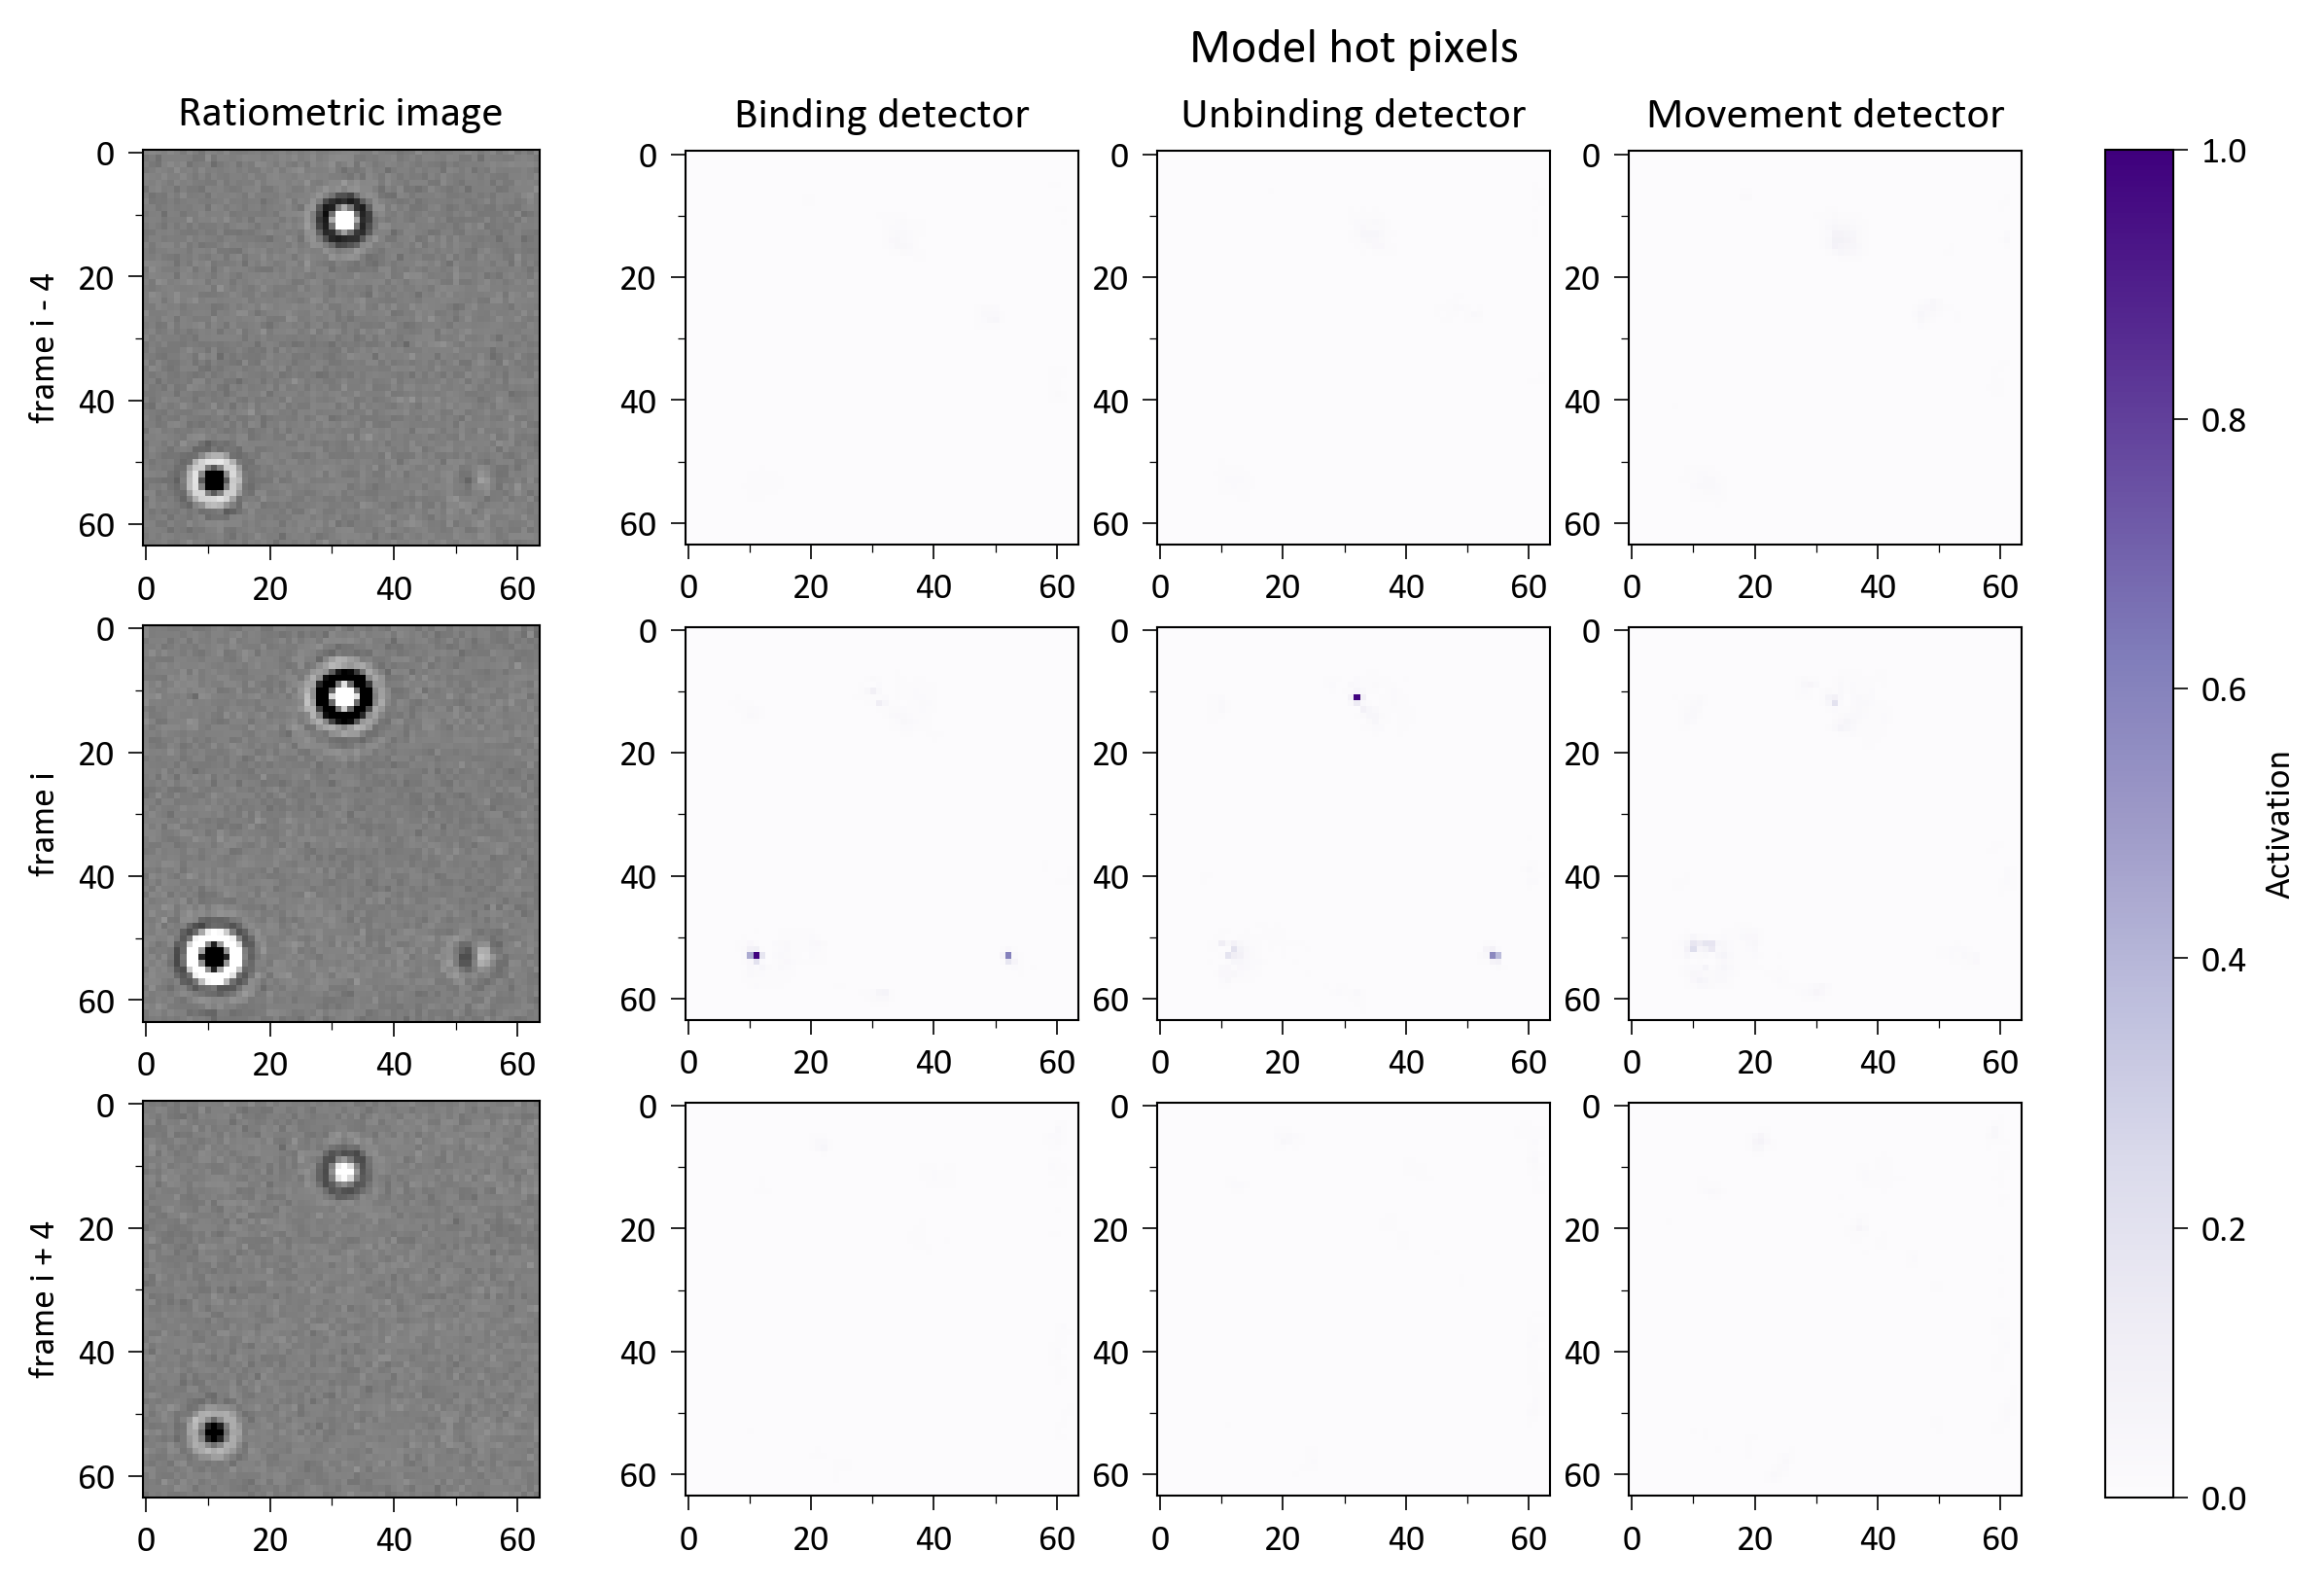

In [194]:
ev_frame = 100 - navg


fig, axs = plt.subplots(3, 4, dpi=300, figsize=(10, 6))

cmap: str = "Purples"

axs[0, 1].set_title("Binding detector")
axs[0, 2].set_title("Unbinding detector")
axs[0, 3].set_title("Movement detector")
axs[0, 0].set_title("Ratiometric image")


diff = 4
axs[0, 1].imshow(
    heatmap[EventDetector.CLASS_BINDING][ev_frame - diff], vmin=0, vmax=1, cmap=cmap
)
axs[0, 2].imshow(
    heatmap[EventDetector.CLASS_UNBINDING][ev_frame - diff], vmin=0, vmax=1, cmap=cmap
)
axs[0, 3].imshow(
    heatmap[EventDetector.CLASS_MOVEMENT][ev_frame - diff], vmin=0, vmax=1, cmap=cmap
)
axs[0, 0].set_ylabel(f"frame i - {diff}")
axs[0, 0].imshow(
    -images[ev_frame - diff] / constants.RATIOMETRIC_RESCALE,
    cmap="gray",
    vmin=-0.01,
    vmax=0.01,
)


axs[1, 1].imshow(
    heatmap[EventDetector.CLASS_BINDING][ev_frame], vmin=0, vmax=1, cmap=cmap
)
axs[1, 2].imshow(
    heatmap[EventDetector.CLASS_UNBINDING][ev_frame], vmin=0, vmax=1, cmap=cmap
)
axs[1, 3].imshow(
    heatmap[EventDetector.CLASS_MOVEMENT][ev_frame], vmin=0, vmax=1, cmap=cmap
)
axs[1, 0].set_ylabel(f"frame i")
axs[1, 0].imshow(
    -images[ev_frame] / constants.RATIOMETRIC_RESCALE,
    cmap="gray",
    vmin=-0.01,
    vmax=0.01,
)


axs[2, 1].imshow(
    heatmap[EventDetector.CLASS_BINDING][ev_frame + diff], vmin=0, vmax=1, cmap=cmap
)
axs[2, 2].imshow(
    heatmap[EventDetector.CLASS_UNBINDING][ev_frame + diff], vmin=0, vmax=1, cmap=cmap
)
im = axs[2, 3].imshow(
    heatmap[EventDetector.CLASS_MOVEMENT][ev_frame + diff], vmin=0, vmax=1, cmap=cmap
)
axs[2, 0].set_ylabel(f"frame i + {diff}")
axs[2, 0].imshow(
    -images[ev_frame + diff] / constants.RATIOMETRIC_RESCALE,
    cmap="gray",
    vmin=-0.01,
    vmax=0.01,
)

plt.colorbar(mappable=im, ax=axs[:, 1:], label="Activation")

for ax in axs.flatten():
    ax.xaxis.set_major_locator(MultipleLocator(20))
    ax.yaxis.set_major_locator(MultipleLocator(20))
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(10))

fig.text(x=0.5, y=0.93, s="Model hot pixels", size=12)

In [ ]:
ax.set_

<Axes: title={'center': 'Ratiometric image'}, ylabel='frame i - 3'>